In [ ]:
# ============================================================
# SOLEMNE II · PCFI261
# Modelo de Ising 1D mediante algoritmo de Metropolis
# Katalina Pimentel Reeves
# ============================================================

# ------------------------------------------------------------
# 1.librerías y configuración gráfica
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
# Paleta de colores
color_main = "#b85c8a"
color_soft = "#e8b7cf"
color_dark = "#7a3b5c"
background = "#fff7fb"

plt.rcParams.update({
    "figure.facecolor": background,
    "axes.facecolor": background,
    "axes.edgecolor": color_soft,
    "axes.labelcolor": color_dark,
    "xtick.color": color_dark,
    "ytick.color": color_dark,
    "text.color": color_dark,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 11
})

In [ ]:
# ------------------------------------------------------------
# 2. Definición de funciones del modelo de Ising
# ------------------------------------------------------------

def energia_por_espin(s, J=1.0):
    return -J * np.sum(s * np.roll(s, -1)) / len(s)
def metropolis_1d(N, T, n_sweeps, J=1.0, seed=42):

    rng = np.random.default_rng(seed)
    s = rng.choice([-1, 1], size=N)

    E_trace = np.zeros(n_sweeps)
    m_trace = np.zeros(n_sweeps)

    for sweep in range(n_sweeps):

        for _ in range(N):

            i = rng.integers(N)

            dE = 2.0 * J * s[i] * (
                s[(i - 1) % N] + s[(i + 1) % N]
            )

            if dE <= 0.0 or rng.random() < np.exp(-dE / T):
                s[i] *= -1

        E_trace[sweep] = energia_por_espin(s, J)
        m_trace[sweep] = abs(s.mean())

    return E_trace, m_trace

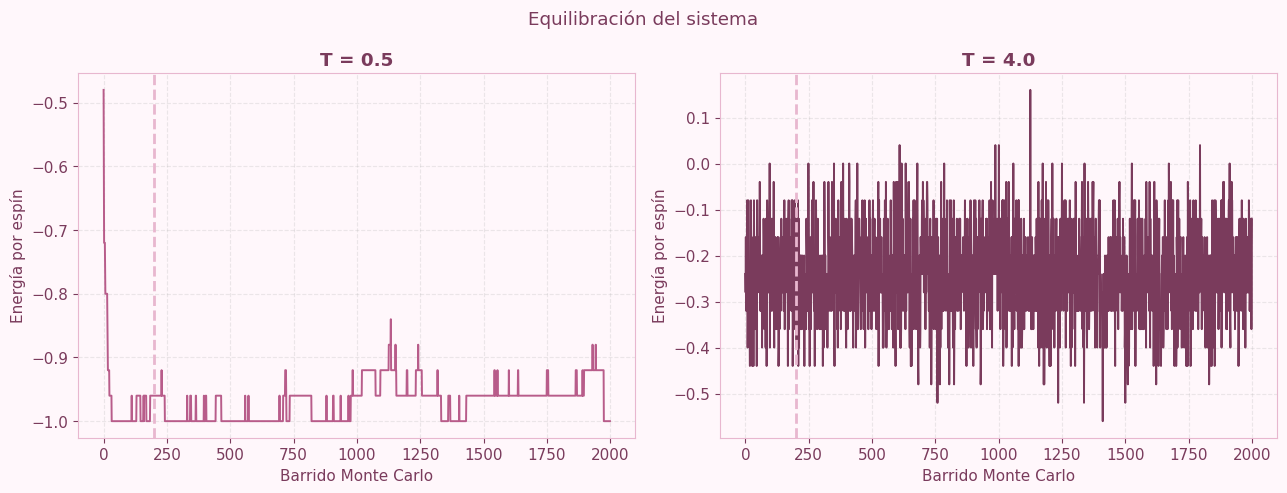

In [ ]:
# ------------------------------------------------------------
# 3. Estudio de equilibración del sistema
# ------------------------------------------------------------
N = 100
n_sweeps = 2000

T_baja = 0.5
T_alta = 4.0

E_baja, _ = metropolis_1d(N, T_baja, n_sweeps, seed=42)
E_alta, _ = metropolis_1d(N, T_alta, n_sweeps, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(E_baja, color=color_main, lw=1.4)
axes[0].axvline(200, color=color_soft, ls="--", lw=2)

axes[0].set_title(f"T = {T_baja}")
axes[0].set_xlabel("Barrido Monte Carlo")
axes[0].set_ylabel("Energía por espín")

axes[1].plot(E_alta, color=color_dark, lw=1.4)
axes[1].axvline(200, color=color_soft, ls="--", lw=2)

axes[1].set_title(f"T = {T_alta}")
axes[1].set_xlabel("Barrido Monte Carlo")
axes[1].set_ylabel("Energía por espín")

plt.suptitle("Equilibración del sistema")
plt.tight_layout()

plt.savefig(
    "fig1_equilibracion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

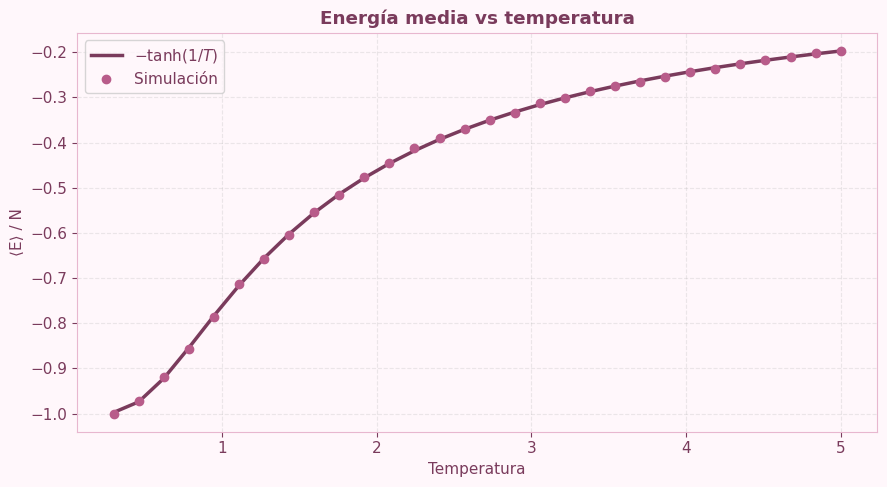

In [ ]:
# ------------------------------------------------------------
# 4. Energía media en función de la temperatura
# ------------------------------------------------------------

burn_in = 200
n_sweeps = 2000
N = 200

temperaturas = np.linspace(0.3, 5.0, 30)

E_sim = []
E_analitica = []

for T in temperaturas:

    E_trace, _ = metropolis_1d(
        N,
        T,
        n_sweeps,
        seed=0
    )

    E_sim.append(E_trace[burn_in:].mean())
    E_analitica.append(-np.tanh(1.0 / T))


fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    temperaturas,
    E_analitica,
    color=color_dark,
    lw=2.5,
    label=r"$-\tanh(1/T)$"
)

ax.plot(
    temperaturas,
    E_sim,
    "o",
    color=color_main,
    ms=6,
    label="Simulación"
)

ax.set_title("Energía media vs temperatura")
ax.set_xlabel("Temperatura")
ax.set_ylabel("⟨E⟩ / N")

ax.legend()

plt.tight_layout()

plt.savefig(
    "fig2_energia_vs_T.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

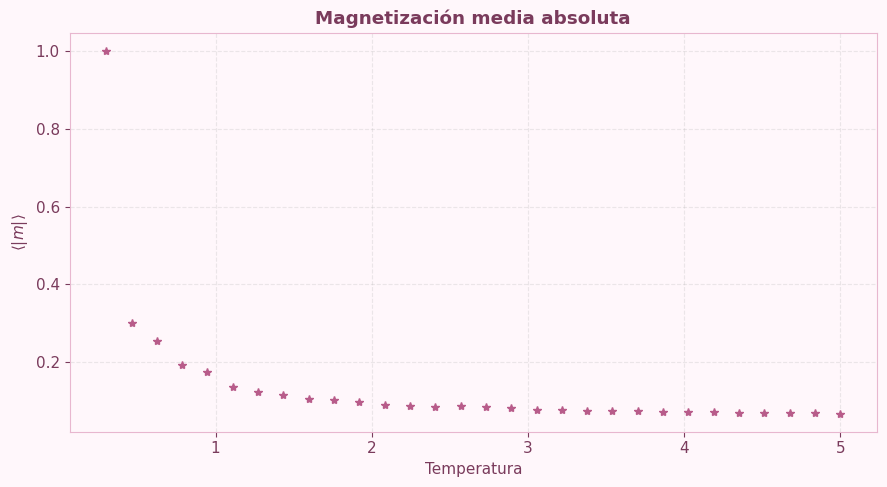

In [ ]:
# ------------------------------------------------------------
# 5. Magnetización media absoluta
# ------------------------------------------------------------
m_sim = []

for T in temperaturas:

    _, m_trace = metropolis_1d(
        N,
        T,
        n_sweeps,
        seed=0
    )

    m_sim.append(m_trace[burn_in:].mean())

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    temperaturas,
    m_sim,
    "*",
    color=color_main,
    ms=6
)

ax.set_title("Magnetización media absoluta")
ax.set_xlabel("Temperatura")
ax.set_ylabel(r"$\langle |m| \rangle$")

plt.tight_layout()

plt.savefig(
    "fig3_magnetizacion_vs_T.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

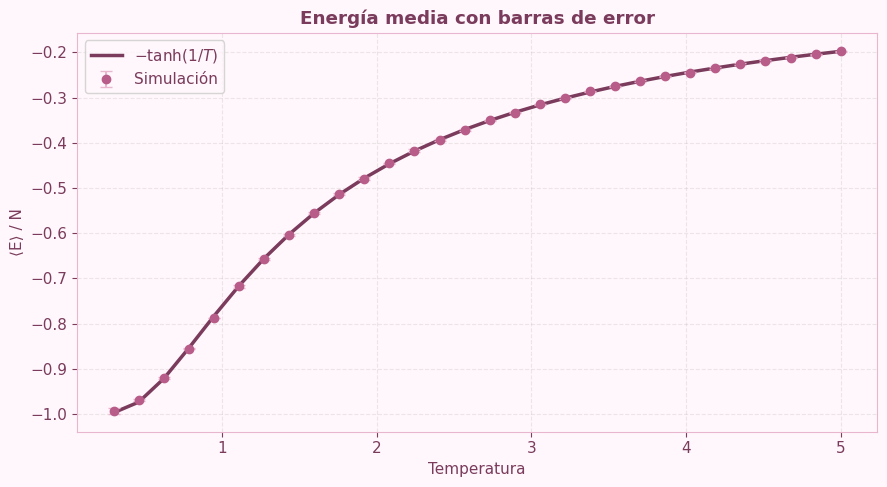

Error medio: 0.00190
Error máximo: 0.00596


In [ ]:
# ------------------------------------------------------------
# 6. Análisis estadístico entre simulaciones
# ------------------------------------------------------------
semillas = [0, 1, 2, 3, 4]

E_replicas = np.zeros(
    (len(semillas), len(temperaturas))
)

for k, seed in enumerate(semillas):

    for j, T in enumerate(temperaturas):

        E_trace, _ = metropolis_1d(
            N,
            T,
            n_sweeps,
            seed=seed
        )

        E_replicas[k, j] = E_trace[burn_in:].mean()

E_media = E_replicas.mean(axis=0)
E_error = E_replicas.std(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    temperaturas,
    E_analitica,
    color=color_dark,
    lw=2.5,
    label=r"$-\tanh(1/T)$"
)

ax.errorbar(
    temperaturas,
    E_media,
    yerr=E_error,
    fmt="o",
    color=color_main,
    ecolor=color_soft,
    capsize=4,
    ms=6,
    label="Simulación"
)

ax.set_title("Energía media con barras de error")
ax.set_xlabel("Temperatura")
ax.set_ylabel("⟨E⟩ / N")

ax.legend()

plt.tight_layout()

plt.savefig(
    "fig4_error_estadistico.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Error medio: {E_error.mean():.5f}")
print(f"Error máximo: {E_error.max():.5f}")

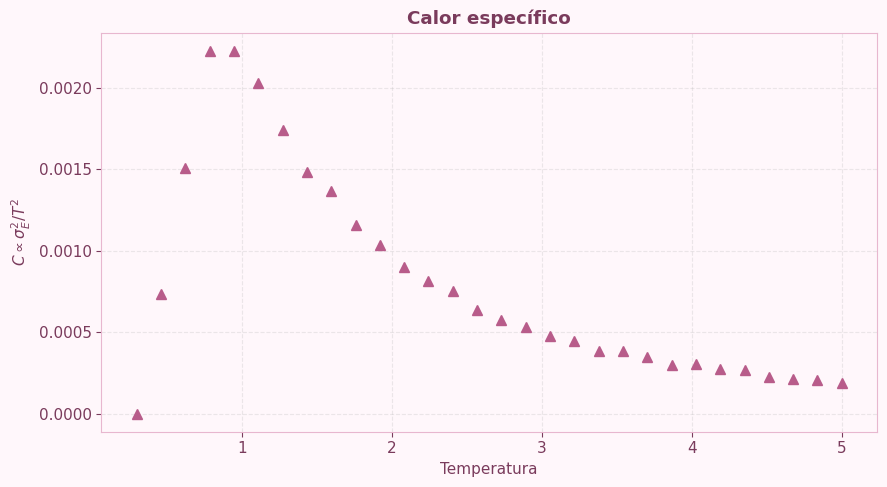

In [ ]:
# ------------------------------------------------------------
# 7. Cálculo del calor específico
# ------------------------------------------------------------

C_sim = []

for T in temperaturas:

    E_trace, _ = metropolis_1d(
        N,
        T,
        n_sweeps,
        seed=0
    )

    C_sim.append(
        E_trace[burn_in:].var() / T**2
    )

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    temperaturas,
    C_sim,
    "^",
    color=color_main,
    ms=7
)

ax.set_title("Calor específico")
ax.set_xlabel("Temperatura")
ax.set_ylabel(r"$C \propto \sigma_E^2 / T^2$")

plt.tight_layout()

plt.savefig(
    "fig5_calor_especifico.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================
# SOLEMNE 2 · PCFI261
# Problema 2 · Modelo de Ising 2D
# Katalina Pimentel Reeves
# ============================================


# ------------------------------------------------------------
# librerias y configuracion grafica
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

color_dark  = "#9D1C4A"
color_main  = "#D94F70"
color_soft  = "#F28AA5"
color_light = "#FFE3EA"
color_line  = "#C73E5D"

In [ ]:
#Algoritmo de Metropolis para Ising 2D
def metropolis_2d(L, T, n_sweeps, J=1.0, seed=42):

    rng = np.random.default_rng(seed)

    s = rng.choice(
        [-1, 1],
        size=(L, L)
    )

    E_trace = np.zeros(n_sweeps)
    m_trace = np.zeros(n_sweeps)

    for sweep in range(n_sweeps):

        for _ in range(L * L):

            i = rng.integers(L)
            j = rng.integers(L)

            vecinos = (
                s[(i - 1) % L, j]
                + s[(i + 1) % L, j]
                + s[i, (j - 1) % L]
                + s[i, (j + 1) % L]
            )

            dE = 2.0 * J * s[i, j] * vecinos

            if dE <= 0.0 or rng.random() < np.exp(-dE / T):
                s[i, j] *= -1

        energia = -J * np.sum(
            s * (
                np.roll(s, -1, axis=0)
                + np.roll(s, -1, axis=1)
            )
        )

        E_trace[sweep] = energia / (L * L)
        m_trace[sweep] = abs(s.mean())

    return s, E_trace, m_trace

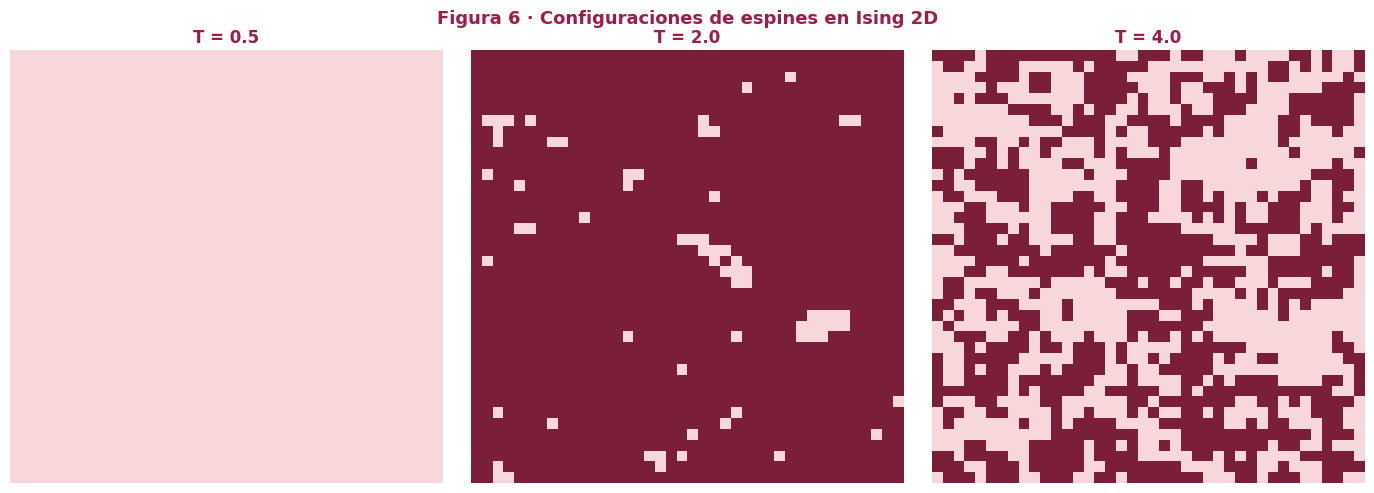

In [ ]:
# ------------------------------------------------------------
#Configuraciones de espines a diferentes temperaturas
# ------------------------------------------------------------

L = 40
n_sweeps = 500

temperaturas = [0.5, 2.0, 4.0]

titulos = [
    "T = 0.5",
    "T = 2.0",
    "T = 4.0"
]


cmap_ising = mcolors.ListedColormap([
    "#7A1E3A",   # espín -1
    "#F8D7DA"    # espín +1
])

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    facecolor="white"
)

for ax, T, titulo in zip(axes, temperaturas, titulos):

    s_final, _, _ = metropolis_2d(
        L,
        T,
        n_sweeps,
        seed=7
    )

    ax.imshow(
        s_final,
        cmap=cmap_ising,
        vmin=-1,
        vmax=1,
        interpolation="nearest"
    )

    ax.set_title(
        titulo,
        fontsize=12,
        color=color_dark,
        fontweight="bold"
    )

    ax.axis("off")

plt.suptitle(
    "Figura 6 · Configuraciones de espines en Ising 2D",
    fontsize=13,
    color=color_dark,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig6_configuraciones_2d.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

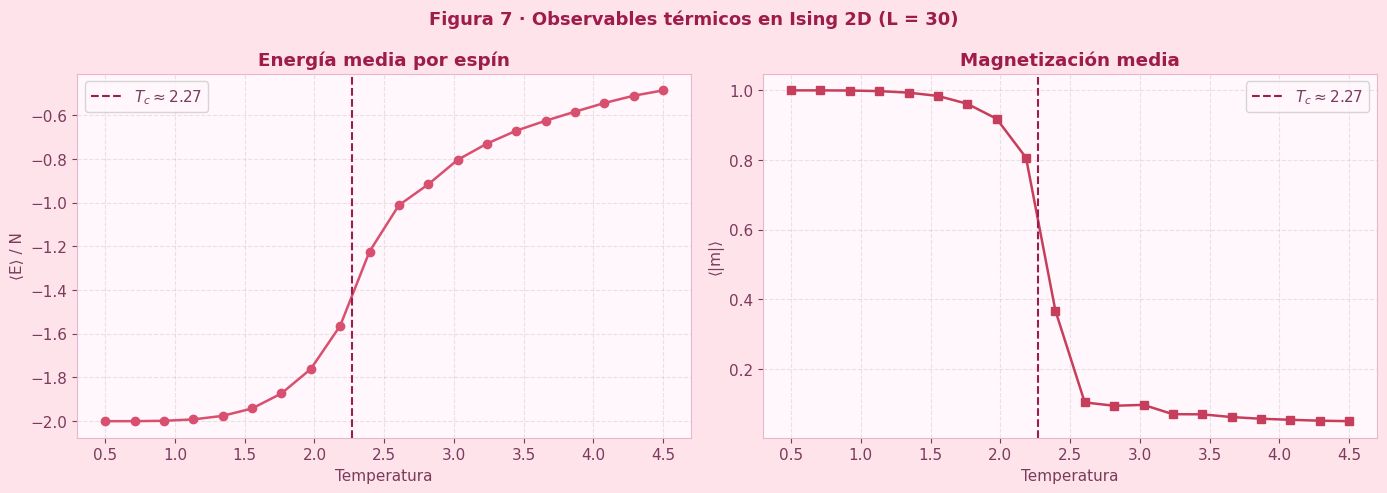

Tc de referencia (Onsager): 2.269
Rango simulado: T = 0.5 a 4.5


In [ ]:
# ------------------------------------------------------------
#Energia en funcion de la temperatura
# ------------------------------------------------------------
L = 30

n_sweeps = 600
burn_in = 150

temperaturas = np.linspace(0.5, 4.5, 20)

E_2d = []
m_2d = []

for T in temperaturas:

    _, E_trace, m_trace = metropolis_2d(
        L,
        T,
        n_sweeps,
        seed=0
    )

    E_2d.append(
        E_trace[burn_in:].mean()
    )

    m_2d.append(
        m_trace[burn_in:].mean()
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    facecolor=color_light
)


# Energía
axes[0].plot(
    temperaturas,
    E_2d,
    "o-",
    color=color_main,
    lw=1.8,
    ms=6
)

axes[0].axvline(
    2.269,
    color=color_dark,
    linestyle="--",
    lw=1.5,
    label=r"$T_c \approx 2.27$"
)

axes[0].set_title(
    "Energía media por espín",
    color=color_dark,
    fontweight="bold"
)

axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("⟨E⟩ / N")

axes[0].grid(
    alpha=0.3,
    linestyle="--"
)

axes[0].legend()


# Magnetización
axes[1].plot(
    temperaturas,
    m_2d,
    "s-",
    color=color_line,
    lw=1.8,
    ms=6
)

axes[1].axvline(
    2.269,
    color=color_dark,
    linestyle="--",
    lw=1.5,
    label=r"$T_c \approx 2.27$"
)

axes[1].set_title(
    "Magnetización media",
    color=color_dark,
    fontweight="bold"
)

axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("⟨|m|⟩")

axes[1].grid(
    alpha=0.3,
    linestyle="--"
)

axes[1].legend()

plt.suptitle(
    f"Figura 7 · Observables térmicos en Ising 2D (L = {L})",
    fontsize=13,
    color=color_dark,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "fig7_observables_2d.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=color_light
)

plt.show()

print(f"Tc de referencia (Onsager): 2.269")

print(
    f"Rango simulado: "
    f"T = {temperaturas[0]:.1f} "
    f"a {temperaturas[-1]:.1f}"
)